WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]


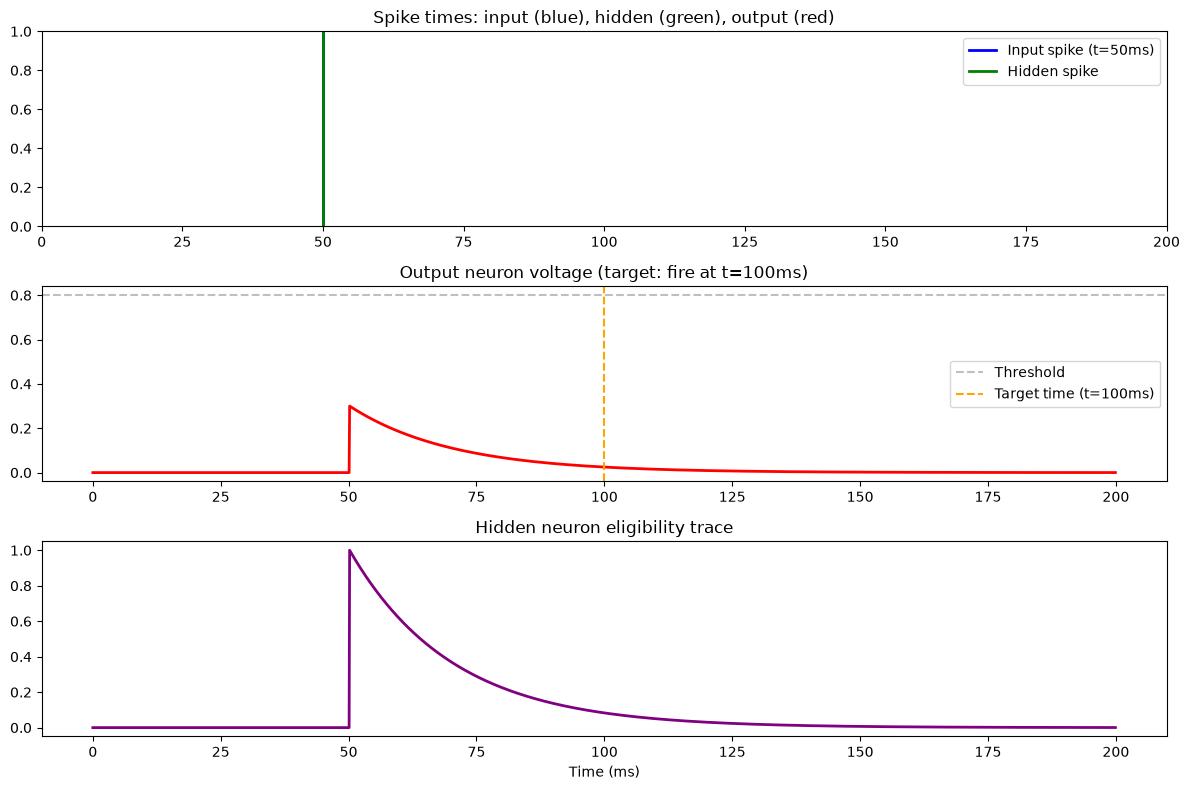

Hidden neuron fired at: [50.1]
Output neuron fired at: []
Current hidden→output weight: 0.3000
Peak eligibility trace: 1.0000

Goal: train weight so output fires at t=100ms


In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

# E-PROP FOUNDATIONS
# Building the three components of e-prop from scratch:
# 1. Eligibility traces (from notebook 10)
# 2. A learning signal from the output error
# 3. Weight update = eligibility trace × learning signal

# We start with the simplest possible e-prop circuit:
# One input neuron, one hidden neuron, and one output neuron
# Task: train the hidden output weight so the output fires at the right time

# Time constants
tau_mem = 10*ms
tau_trace = 20*ms    # eligibility trace decay
tau_out = 20*ms      # output neuron time constant

# Input neuron fires at t=50ms (stimulus)
input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)

# Hidden neuron (receives input, sends to output)
eqs_hidden = '''
dv/dt = -v/tau_mem : 1
detrace/dt = -etrace/tau_trace : 1   # eligibility trace
'''
hidden = NeuronGroup(1, eqs_hidden, 
                     threshold='v>0.8', reset='v=0; etrace+=1.0',
                     method='exact')
hidden.v = 0
hidden.etrace = 0

# Output neuron (ideally fires at t=100ms)
eqs_out = '''
dv/dt = -v/tau_out : 1
'''
output = NeuronGroup(1, eqs_out,
                     threshold='v>0.8', reset='v=0',
                     method='exact')
output.v = 0

# Input to hidden synapse (fixed weight)
S_in = Synapses(input_neuron, hidden, 'w:1', on_pre='v_post += w')
S_in.connect()
S_in.w = 0.9  # strong enough to make the hidden synapse fire

# Hidden → output synapse (this is what we'll train)
S_out = Synapses(hidden, output, 'w:1', on_pre='v_post += w')
S_out.connect()
S_out.w = 0.3  # starts out weak, so the output doesn't fire yet

# Monitor
spike_mon_h = SpikeMonitor(hidden)
spike_mon_o = SpikeMonitor(output)
voltage_mon_o = StateMonitor(output, 'v', record=True)
trace_mon = StateMonitor(hidden, 'etrace', record=True)

run(200*ms)

# Plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8))

# Input and hidden spikes
ax1.axvline(x=50, color='blue', linewidth=2, label='Input spike (t=50ms)')
if len(spike_mon_h.t) > 0:
    for t in spike_mon_h.t/ms:
        ax1.axvline(x=t, color='green', linewidth=2, label='Hidden spike')
if len(spike_mon_o.t) > 0:
    for t in spike_mon_o.t/ms:
        ax1.axvline(x=t, color='red', linewidth=2, label='Output spike')
ax1.set_title('Spike times: input (blue), hidden (green), output (red)')
ax1.legend()
ax1.set_xlim(0, 200)

# Output voltage
ax2.plot(voltage_mon_o.t/ms, voltage_mon_o.v[0], color='red', linewidth=2)
ax2.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Threshold')
ax2.axvline(x=100, color='orange', linestyle='--', label='Target time (t=100ms)')
ax2.set_title('Output neuron voltage (target: fire at t=100ms)')
ax2.legend()

# Eligibility trace
ax3.plot(trace_mon.t/ms, trace_mon.etrace[0], color='purple', linewidth=2)
ax3.set_title('Hidden neuron eligibility trace')
ax3.set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()

print(f"Hidden neuron fired at: {spike_mon_h.t/ms}")
print(f"Output neuron fired at: {spike_mon_o.t/ms}")
print(f"Current hidden→output weight: {S_out.w[0]:.4f}")
print(f"Peak eligibility trace: {max(trace_mon.etrace[0]):.4f}")
print(f"\nGoal: train weight so output fires at t=100ms")

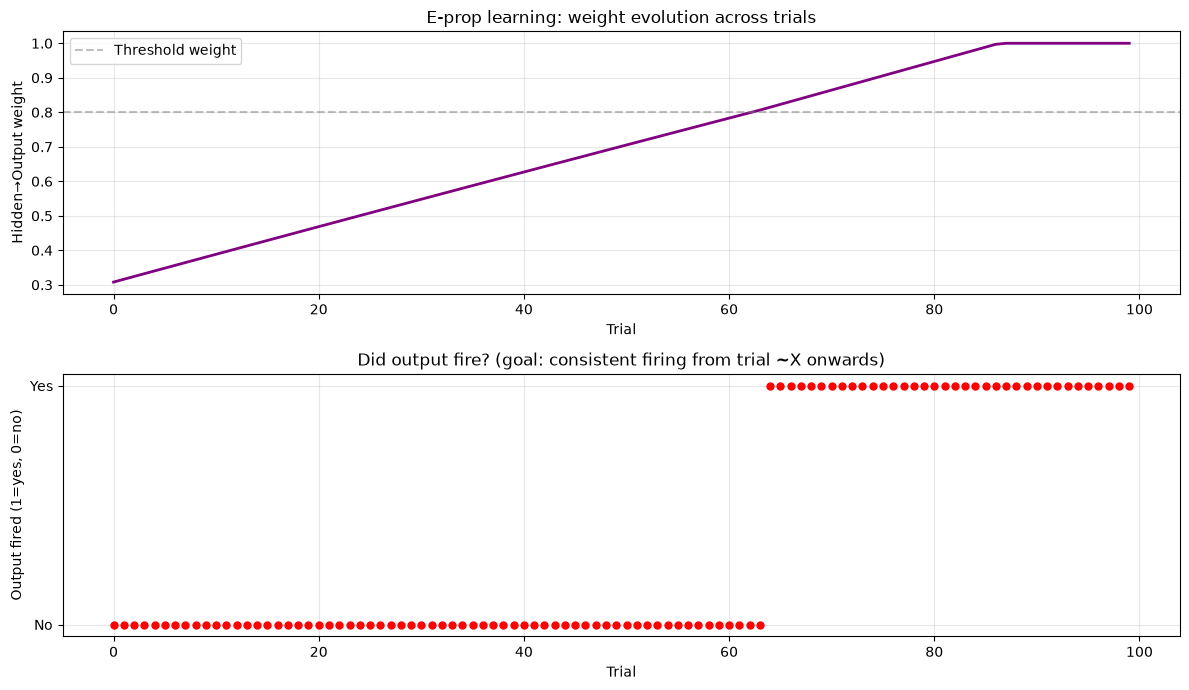

Starting weight: 0.3000
Final weight: 1.0000
First trial output fired: 64
Trials where output fired: 36/100


In [4]:
start_scope()

tau_mem = 10*ms
tau_trace = 20*ms
tau_out = 20*ms
learning_rate = 0.1 # increasing the learning weight from 0.1 to 0.2
n_trials = 100  # increasing the number of training trials from 50 to 100

# Tracks the weight and output firing across trials
weights = []
output_fired = []

w = 0.3  # starting weight

for trial in range(n_trials):
    start_scope()
    
    input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)
    
    eqs_hidden = '''
    dv/dt = -v/tau_mem : 1
    detrace/dt = -etrace/tau_trace : 1
    '''
    hidden = NeuronGroup(1, eqs_hidden,
                        threshold='v>0.8', reset='v=0; etrace+=1.0',
                        method='exact')
    hidden.v = 0
    hidden.etrace = 0
    
    eqs_out = '''
    dv/dt = -v/tau_out : 1
    '''
    output = NeuronGroup(1, eqs_out,
                        threshold='v>0.8', reset='v=0',
                        method='exact')
    output.v = 0
    
    S_in = Synapses(input_neuron, hidden, 'w_in:1', on_pre='v_post += w_in')
    S_in.connect()
    S_in.w_in = 0.9
    
    S_out = Synapses(hidden, output, 'w_out:1', on_pre='v_post += w_out')
    S_out.connect()
    S_out.w_out = w  # current weight
    
    spike_mon_h = SpikeMonitor(hidden)
    spike_mon_o = SpikeMonitor(output)
    trace_mon = StateMonitor(hidden, 'etrace', record=True)
    voltage_mon_o = StateMonitor(output, 'v', record=True)
    
    run(200*ms)
    
    # E-PROP LEARNING RULE
    # The output ideally fires at t=100ms
    # Learning signal: the difference between the target and actual output voltage at t=100ms
    target_idx = int(100/0.1)  # index for t=100ms
    actual_voltage = voltage_mon_o.v[0][target_idx]
    target_voltage = 1.0  # voltage threshold is ideally at t=100ms
    
    # Learning signal = error (difference between the output and the target)
    learning_signal = target_voltage - actual_voltage
    
    # Eligibility trace at t=100ms
    trace_at_target = trace_mon.etrace[0][target_idx]
    
    # Weight update = learning rate × learning signal × eligibility trace
    delta_w = learning_rate * learning_signal * trace_at_target
    w = np.clip(w + delta_w, 0, 1)
    
    weights.append(w)
    output_fired.append(1 if len(spike_mon_o.t) > 0 else 0)

# Plot learning progress
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

ax1.plot(range(n_trials), weights, color='purple', linewidth=2)
ax1.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Threshold weight')
ax1.set_xlabel('Trial')
ax1.set_ylabel('Hidden→Output weight')
ax1.set_title('E-prop learning: weight evolution across trials')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(n_trials), output_fired, 'o', color='red', markersize=5)
ax2.set_xlabel('Trial')
ax2.set_ylabel('Output fired (1=yes, 0=no)')
ax2.set_title('Did output fire? (goal: consistent firing from trial ~X onwards)')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['No', 'Yes'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Starting weight: 0.3000")
print(f"Final weight: {weights[-1]:.4f}")
print(f"First trial output fired: {next((i for i, f in enumerate(output_fired) if f), 'never')}")
print(f"Trials where output fired: {sum(output_fired)}/{n_trials}")

## E-Prop Foundations — Observations & Results

### What is e-prop?
Eligibility propagation (e-prop) is a biologically plausible learning 
algorithm for spiking neural networks (SNNs) introduced by Bellec et al. (2020),
it bridges the gap between local learning rules (like STDP) and the task 
performance achievable with backpropagation, using three components working 
together:

1. **Eligibility traces** — synapse-local decaying memory of recent 
   pre/post-synaptic activity (from notebook 10)
2. **Learning signal** — top-down error signal that indicates how far the 
   network's output has deviated from the target
3. **Weight update** — eligibility trace × learning signal

Unlike backpropagation through time (BPTT), e-prop is:
- **Online** — the updates happen trial by trial, not after seeing the data altogether,
- **Local in time** — no need to store the entire history of activations, and
- **Nearly local in space** — the learning signal flows only one layer back

This is what makes e-prop a serious candidate for implementation on neuromorphic 
hardware like Intel's Loihi 2, where global gradient computation is 
physically impossible.

### Architecture
The simplest possible e-prop circuit:
- **Input neuron** — fires at t=50ms (the stimulus)
- **Hidden neuron** — receives input, and maintains eligibility trace
- **Output neuron** — target: fires at t=100ms
- **Trainable synapse** — hidden→output weight, updated by e-prop

**Task:** train the hidden→output weight so that the output neuron reliably 
fires after receiving the hidden neuron's spike.

### Phase 1: Initial state (w=0.3)
With the starting weight of 0.3:
- The input fires at t=50ms → hidden fires at t=50.1ms (one-step delay)
- The hidden spike sends a voltage kick of 0.3 to output, which is below the threshold of 0.8
- The output never fires
- The eligibility trace peaks at 1.0 at t=50ms, and eventually decays to approximately 0.08 by t=100ms

The eligibility trace at t=100ms (0.08) is small because the hidden neuron 
fired 50ms earlier and the trace has decayed with tau_trace=20ms. This 
means that each weight update is modest, and requires many trials to converge.

### Phase 2: E-prop learning (100 trials, lr=0.2)
**Weight update rule:**
- learning_signal = target_voltage - actual_output_voltage at t=100ms
- trace_at_target = eligibility_trace at t=100ms
- Δw = learning_rate × learning_signal × trace_at_target
- w = clip(w + Δw, 0, 1)


**Results:**

| Metric | Value |
|--------|-------|
| Starting weight | 0.3000 |
| Final weight | 1.0000 |
| First trial output fired | Trial 64 |
| Trials firing after convergence | 36/36 (100%) |
| Total successful trials | 36/100 |

**Weight evolution:** a clean linear climb from 0.3 to 1.0 across 100 
trials, saturating at the clip ceiling once the task is solved.

**Output firing:** sharp transition at trial 64 that's silent for trials 0-63, while 
consistently firing for trials 64-100 with zero failures after convergence.

### Key findings

**Finding 1: e-prop drives reliable task learning**
Starting from a weight too weak to drive output firing at 0.3, the e-prop 
incrementally strengthened the hidden→output connection over 64 trials 
until the output reliably fired. This transition is sharp and stable, not showing 
oscillation or regression after convergence.

**Finding 2: learning stops automatically at convergence**
Once the output fires, the learning signal (target → actual) approaches 
zero, as the output voltage reaches its threshold. Hence, the weight update 
effectively stops, explaining why the weight saturates cleanly at 1.0 
rather than continuing to grow.

**Finding 3: eligibility trace decay limits learning speed**
The hidden neuron fires at t=50ms but the target is t=100ms, which is a 50ms 
gap. With tau_trace=20ms, the trace decays to e^(-50/20) ≈ 0.08 by the 
target time. Each weight update is therefore small (0.2 × error × 0.08), 
requiring ~64 trials to converge, reducing the gap between hidden firing 
and target time, or increasing tau_trace would accelerate convergence, referencing 
a direct demonstration of the credit assignment window from notebook 11.

**Finding 4: contrast with STDP**
STDP (notebook 02) strengthened synapses based purely on spike timing 
coincidence with no notion of task correctness.
E-prop adds the learning signal component, allowing the network to learn a specific target output 
rather than just correlating activity, this being the key functional 
difference between the two algorithms.

### Connection to previous notebooks
- **Notebook 10 (eligibility traces):** the etrace mechanism here is 
  identical — spikes up on firing, and decays with tau_trace
- **Notebook 11 (delayed reward):** the 50ms gap between hidden firing 
  and target time is the temporal credit assignment problem, and the trace bridges this gap
- **Notebook 12 (reward prediction error):** the learning signal here 
  is a simplified version of the prediction error signal — both measure 
  the difference between expected and actual output

### What's next (notebook 02)
Notebook 01 trained a single synapse to drive firing at a fixed time, 
Notebook 02 will tackle precise spike timing — training the network to 
fire at a specific target time rather than just "sometime after the 
input". This requires a more nuanced learning signal that encodes not 
just whether the output fired, but when.